# 04 - Analisis de Hosts
## Valencia Airbnb Investment Intelligence

Research question:
- RQ5: Que perfil de host maximiza la rentabilidad?

Contenido:
1. Segmentacion de hosts (Amateur / Semi-pro / Profesional)
2. Performance por segmento
3. Superhost vs Regular (detalle)
4. Caracteristicas del host mas rentable
5. Estrategia optima para un nuevo inversor

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
import sys

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

PROJECT_ROOT = Path(r'C:\Users\User\Desktop\GitHub\PROYECTO FINAL FINAL\airbnb_valencia')
sys.path.insert(0, str(PROJECT_ROOT))

from config.config import (
    ALPHA, HOST_AMATEUR_MAX, HOST_SEMIPRO_MAX,
    COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT,
    COLOR_GOOD, COLOR_WARN, COLOR_BAD,
    FIG_DPI, FIG_SIZE_WIDE, FIG_SIZE_SQ
)

PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed'
REPORTS_PATH   = PROJECT_ROOT / 'reports' / 'figures'
REPORTS_PATH.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

def save_fig(name):
    plt.savefig(REPORTS_PATH / name, dpi=FIG_DPI, bbox_inches='tight')
    print(f'Guardado: {name}')

print('Setup OK')

Setup OK


## 1. Carga de datos

In [2]:
df = pd.read_csv(PROCESSED_PATH / 'listings_clean.csv', low_memory=False)

# Fix superhost column
df['superhost_num'] = pd.to_numeric(
    df['host_is_superhost'].map({True:1, False:0, 't':1, 'f':0, 1:1, 0:0}),
    errors='coerce'
)
df['host_is_superhost_bool'] = df['superhost_num'] == 1

print(f'listings_clean: {df.shape}')
print(f'\nSegmentos de host:')
print(df['host_segment'].value_counts())
print(f'\nSuperhost:')
print(df['host_is_superhost_bool'].value_counts())
print(f'Nulls superhost: {df["superhost_num"].isna().sum()}')

listings_clean: (7780, 73)

Segmentos de host:
host_segment
Profesional    2893
Semi-pro       2559
Amateur        2328
Name: count, dtype: int64

Superhost:
host_is_superhost_bool
False    5350
True     2430
Name: count, dtype: int64
Nulls superhost: 390


## 2. Segmentacion de Hosts: Amateur / Semi-pro / Profesional

In [3]:
# Estadisticas por segmento
seg_stats = df.groupby('host_segment').agg(
    n_listings       = ('id', 'count'),
    n_hosts          = ('host_id', 'nunique'),
    median_price     = ('price_eur', 'median'),
    median_revenue   = ('estimated_revenue_l365d', 'median'),
    median_occupancy = ('estimated_occupancy_l365d', 'median'),
    median_rating    = ('review_scores_rating', 'median'),
    pct_superhost    = ('superhost_num', 'mean'),
    median_response  = ('host_response_rate', 'median'),
).round(2)
seg_stats['pct_superhost'] = (seg_stats['pct_superhost'] * 100).round(1)
seg_stats = seg_stats.reindex(['Amateur', 'Semi-pro', 'Profesional'])

print('=== ESTADISTICAS POR SEGMENTO DE HOST ===')
display(seg_stats)

# Kruskal-Wallis test
groups_rev = [df[df['host_segment'] == s]['estimated_revenue_l365d'].dropna()
              for s in ['Amateur', 'Semi-pro', 'Profesional']]
stat, p = stats.kruskal(*groups_rev)
print(f'\nKruskal-Wallis (ingresos por segmento): stat={stat:.2f}, p={p:.6f}')
print(f'{"Diferencias significativas (p<0.05)" if p < ALPHA else "Sin diferencias significativas"}')

groups_price = [df[df['host_segment'] == s]['price_eur'].dropna()
                for s in ['Amateur', 'Semi-pro', 'Profesional']]
stat2, p2 = stats.kruskal(*groups_price)
print(f'\nKruskal-Wallis (precio por segmento): stat={stat2:.2f}, p={p2:.6f}')
print(f'{"Diferencias significativas (p<0.05)" if p2 < ALPHA else "Sin diferencias significativas"}')

=== ESTADISTICAS POR SEGMENTO DE HOST ===


,n_listings,n_hosts,median_price,median_revenue,median_occupancy,median_rating,pct_superhost,median_response
host_segment,,,,,,,,
Amateur,2328,2328,100.00,7200.00,72.00,4.80,34.00,1.00
Semi-pro,2559,919,97.00,6120.00,66.00,4.78,38.00,1.00
Profesional,2893,201,108.00,4416.00,40.00,4.75,27.00,1.00



Kruskal-Wallis (ingresos por segmento): stat=36.00, p=0.000000
Diferencias significativas (p<0.05)

Kruskal-Wallis (precio por segmento): stat=147.66, p=0.000000
Diferencias significativas (p<0.05)


Guardado: 22_host_segment_performance.png


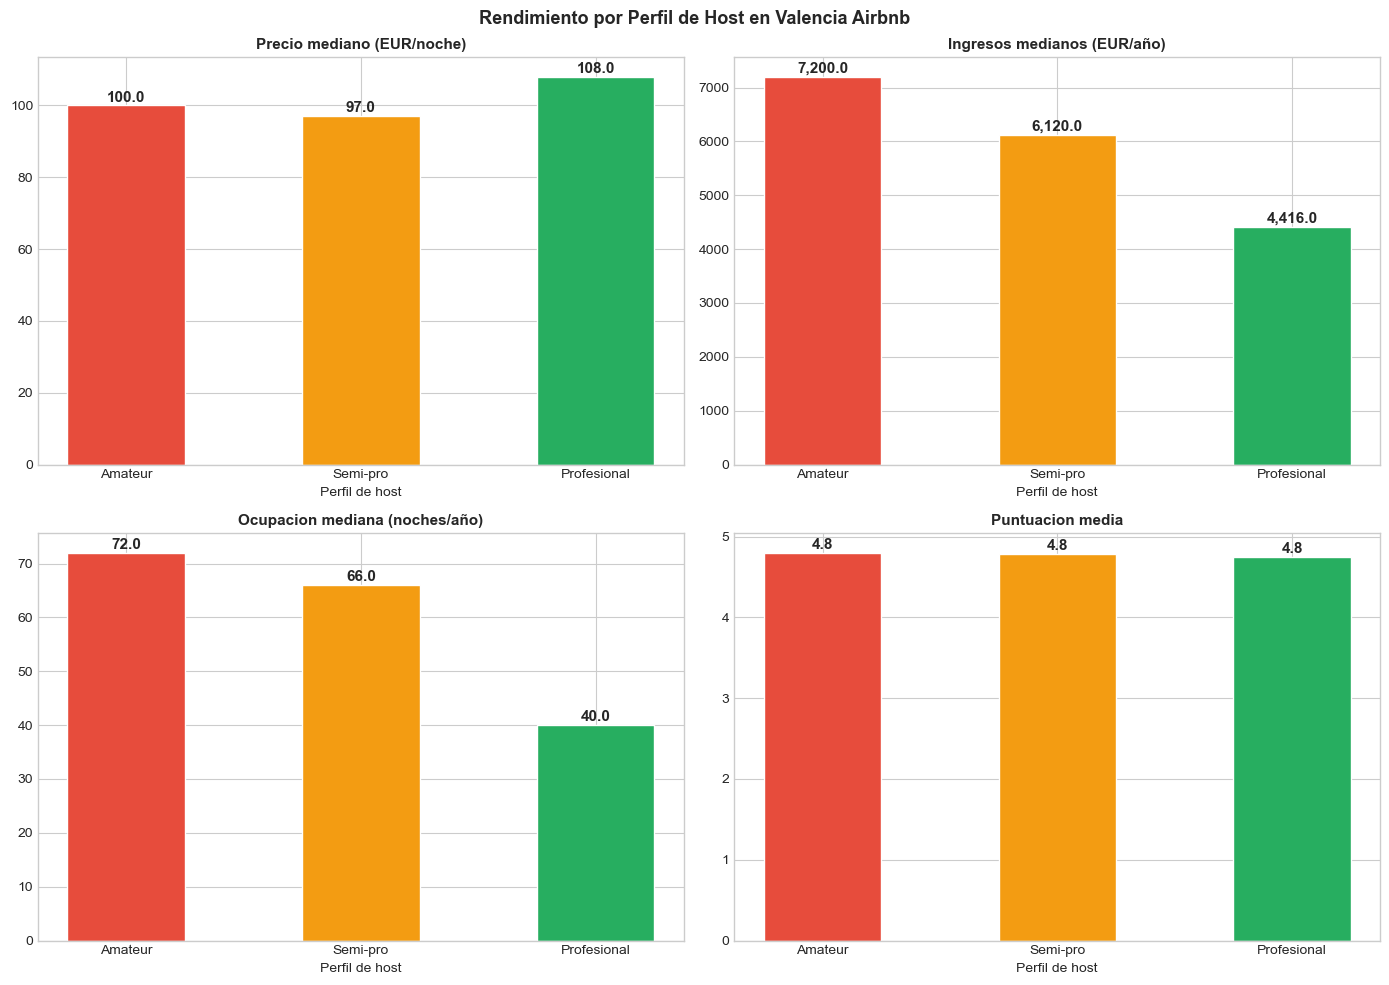

In [4]:
# Visualizacion comparativa por segmento
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
segment_order = ['Amateur', 'Semi-pro', 'Profesional']
colors_seg = [COLOR_BAD, COLOR_WARN, COLOR_GOOD]

metrics = [
    ('median_price',     'Precio mediano (EUR/noche)', axes[0,0]),
    ('median_revenue',   'Ingresos medianos (EUR/año)', axes[0,1]),
    ('median_occupancy', 'Ocupacion mediana (noches/año)', axes[1,0]),
    ('median_rating',    'Puntuacion media', axes[1,1]),
]

for col, label, ax in metrics:
    vals = [float(seg_stats.loc[s, col]) if s in seg_stats.index else 0
            for s in segment_order]
    bars = ax.bar(segment_order, vals, color=colors_seg, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:,.1f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Perfil de host')

plt.suptitle('Rendimiento por Perfil de Host en Valencia Airbnb',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('22_host_segment_performance.png')
plt.show()

## 3. Distribucion de Ingresos por Segmento

Guardado: 23_revenue_distribution_by_segment.png


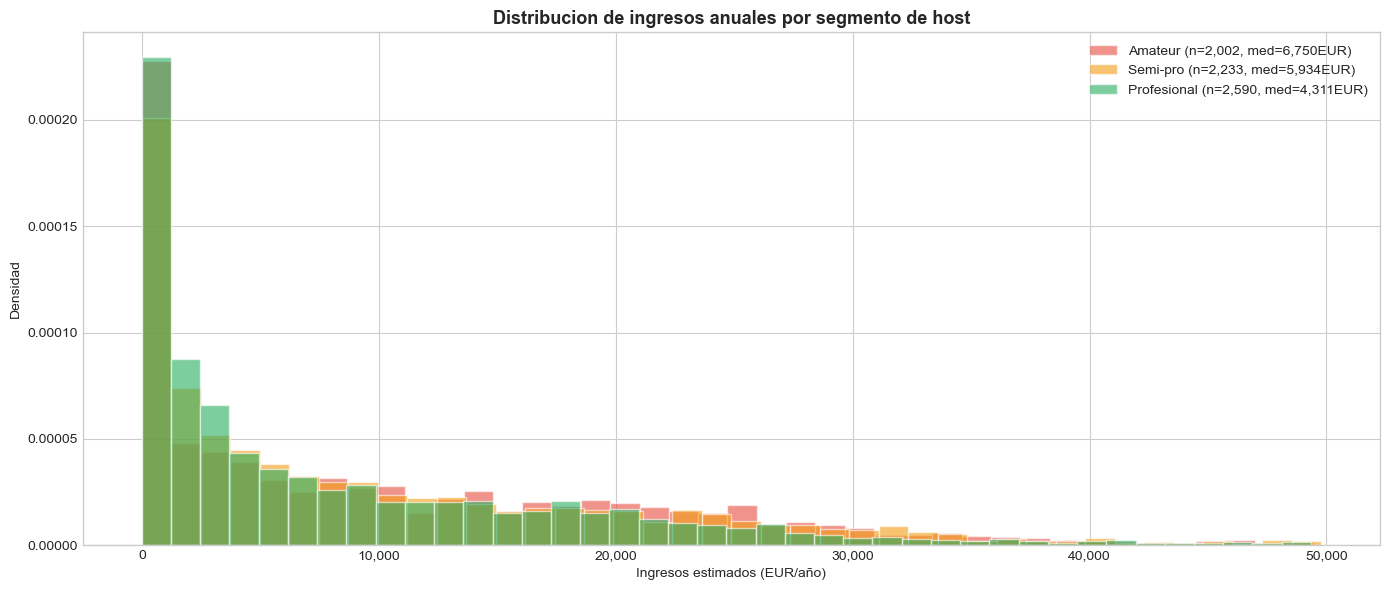

In [5]:
fig, ax = plt.subplots(figsize=FIG_SIZE_WIDE)

for seg, color in zip(segment_order, colors_seg):
    data = df[df['host_segment'] == seg]['estimated_revenue_l365d'].dropna()
    data = data[data <= 50000]
    ax.hist(data, bins=40, alpha=0.6, color=color,
            label=f'{seg} (n={len(data):,}, med={data.median():,.0f}EUR)',
            edgecolor='white', density=True)

ax.set_title('Distribucion de ingresos anuales por segmento de host',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ingresos estimados (EUR/año)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.tight_layout()
save_fig('23_revenue_distribution_by_segment.png')
plt.show()

## 4. Superhost vs Regular - Analisis Detallado

In [6]:
# Comparacion completa Superhost vs Regular
sh_stats = df.groupby('host_is_superhost_bool').agg(
    n_listings       = ('id', 'count'),
    n_hosts          = ('host_id', 'nunique'),
    median_price     = ('price_eur', 'median'),
    mean_price       = ('price_eur', 'mean'),
    median_revenue   = ('estimated_revenue_l365d', 'median'),
    median_occupancy = ('estimated_occupancy_l365d', 'median'),
    median_rating    = ('review_scores_rating', 'median'),
    median_response  = ('host_response_rate', 'median'),
    median_acceptance= ('host_acceptance_rate', 'median'),
    instant_book_pct = ('instant_bookable', 'mean'),
).round(3)
sh_stats.index = ['Host Regular', 'Superhost']
sh_stats['instant_book_pct'] = (sh_stats['instant_book_pct'] * 100).round(1)

print('=== SUPERHOST vs HOST REGULAR ===')
display(sh_stats.T)

# Revenue uplift
sh_med  = df[df['host_is_superhost_bool'] == True]['estimated_revenue_l365d'].dropna().median()
reg_med = df[df['host_is_superhost_bool'] == False]['estimated_revenue_l365d'].dropna().median()
uplift  = (sh_med - reg_med) / reg_med * 100
print(f'\nSuperhost mediana: {sh_med:,.0f} EUR/año')
print(f'Regular mediana:   {reg_med:,.0f} EUR/año')
print(f'Uplift: +{uplift:.1f}%')

=== SUPERHOST vs HOST REGULAR ===


,Host Regular,Superhost
n_listings,5350.00,2430.00
n_hosts,2269.00,1179.00
median_price,100.00,105.00
mean_price,111.00,116.17
median_revenue,2904.00,14136.00
median_occupancy,30.00,156.00
median_rating,4.74,4.86
median_response,1.00,1.00
median_acceptance,0.99,0.99
instant_book_pct,50.50,40.50



Superhost mediana: 14,136 EUR/año
Regular mediana:   2,904 EUR/año
Uplift: +386.8%


Guardado: 24_radar_superhost_vs_regular.png


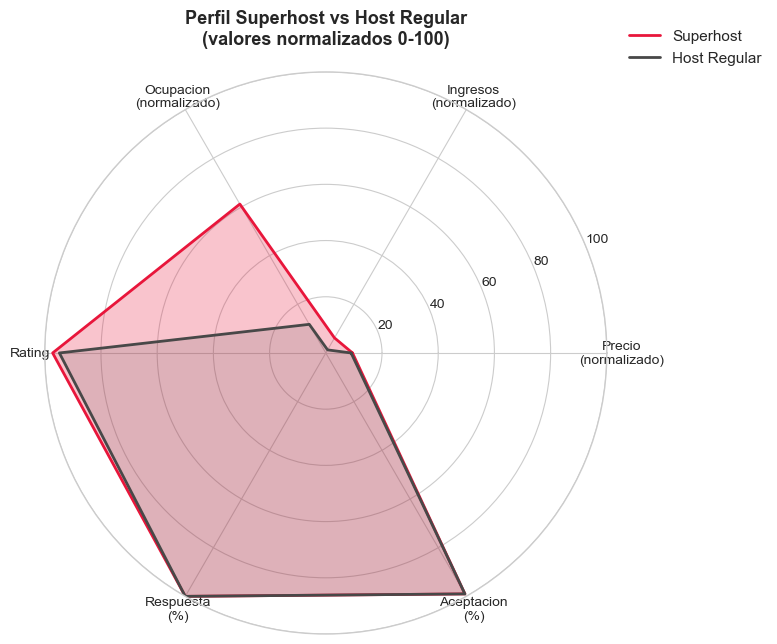

In [7]:
# Radar chart: perfil Superhost vs Regular
categories = ['Precio\n(normalizado)', 'Ingresos\n(normalizado)',
              'Ocupacion\n(normalizado)', 'Rating', 'Respuesta\n(%)',
              'Aceptacion\n(%)']

sh_row  = df[df['host_is_superhost_bool'] == True]
reg_row = df[df['host_is_superhost_bool'] == False]

def norm(series, mn, mx):
    return ((series.median() - mn) / (mx - mn) * 100) if mx != mn else 50

sh_vals = [
    norm(sh_row['price_eur'],               df['price_eur'].min(),               df['price_eur'].max()),
    norm(sh_row['estimated_revenue_l365d'],  df['estimated_revenue_l365d'].min(), df['estimated_revenue_l365d'].max()),
    norm(sh_row['estimated_occupancy_l365d'],df['estimated_occupancy_l365d'].min(),df['estimated_occupancy_l365d'].max()),
    sh_row['review_scores_rating'].median() / 5 * 100,
    sh_row['host_response_rate'].median() * 100 if sh_row['host_response_rate'].median() <= 1 else sh_row['host_response_rate'].median(),
    sh_row['host_acceptance_rate'].median() * 100 if sh_row['host_acceptance_rate'].median() <= 1 else sh_row['host_acceptance_rate'].median(),
]
reg_vals = [
    norm(reg_row['price_eur'],               df['price_eur'].min(),               df['price_eur'].max()),
    norm(reg_row['estimated_revenue_l365d'],  df['estimated_revenue_l365d'].min(), df['estimated_revenue_l365d'].max()),
    norm(reg_row['estimated_occupancy_l365d'],df['estimated_occupancy_l365d'].min(),df['estimated_occupancy_l365d'].max()),
    reg_row['review_scores_rating'].median() / 5 * 100,
    reg_row['host_response_rate'].median() * 100 if reg_row['host_response_rate'].median() <= 1 else reg_row['host_response_rate'].median(),
    reg_row['host_acceptance_rate'].median() * 100 if reg_row['host_acceptance_rate'].median() <= 1 else reg_row['host_acceptance_rate'].median(),
]

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
sh_vals  += sh_vals[:1]
reg_vals += reg_vals[:1]
angles   += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, sh_vals,  color=COLOR_PRIMARY, linewidth=2, label='Superhost')
ax.fill(angles, sh_vals,  color=COLOR_PRIMARY, alpha=0.25)
ax.plot(angles, reg_vals, color=COLOR_SECONDARY, linewidth=2, label='Host Regular')
ax.fill(angles, reg_vals, color=COLOR_SECONDARY, alpha=0.15)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 100)
ax.set_title('Perfil Superhost vs Host Regular\n(valores normalizados 0-100)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
save_fig('24_radar_superhost_vs_regular.png')
plt.show()

## 5. Que tienen en comun los hosts mas rentables?

In [8]:
# Top 10% por ingresos
threshold = df['estimated_revenue_l365d'].quantile(0.90)
top_hosts = df[df['estimated_revenue_l365d'] >= threshold].copy()
rest_hosts = df[df['estimated_revenue_l365d'] < threshold].copy()

print(f'Top 10% por ingresos: threshold = {threshold:,.0f} EUR/año')
print(f'N listings top 10%:   {len(top_hosts):,}')
print(f'N listings resto:     {len(rest_hosts):,}')

comparison = pd.DataFrame({
    'Top 10%': [
        top_hosts['price_eur'].median(),
        top_hosts['estimated_revenue_l365d'].median(),
        top_hosts['estimated_occupancy_l365d'].median(),
        top_hosts['review_scores_rating'].median(),
        top_hosts['accommodates'].median(),
        top_hosts['bedrooms'].median(),
        top_hosts['superhost_num'].mean() * 100,
        top_hosts['instant_bookable'].mean() * 100,
        top_hosts['host_response_rate'].median() * 100,
    ],
    'Resto (90%)': [
        rest_hosts['price_eur'].median(),
        rest_hosts['estimated_revenue_l365d'].median(),
        rest_hosts['estimated_occupancy_l365d'].median(),
        rest_hosts['review_scores_rating'].median(),
        rest_hosts['accommodates'].median(),
        rest_hosts['bedrooms'].median(),
        rest_hosts['superhost_num'].mean() * 100,
        rest_hosts['instant_bookable'].mean() * 100,
        rest_hosts['host_response_rate'].median() * 100,
    ]
}, index=['Precio mediano (EUR)', 'Ingresos medianos (EUR/año)', 'Ocupacion mediana (noches)',
          'Rating medio', 'Capacidad media (personas)', 'Habitaciones medianas',
          '% Superhost', '% Instant Bookable', '% Tasa de respuesta']).round(1)

display(comparison)

# Estadisticas significativas
for metric_name, col in [
    ('Precio', 'price_eur'),
    ('Ingresos', 'estimated_revenue_l365d'),
    ('Rating', 'review_scores_rating'),
    ('Ocupacion', 'estimated_occupancy_l365d'),
]:
    g1 = top_hosts[col].dropna()
    g2 = rest_hosts[col].dropna()
    _, p = stats.mannwhitneyu(g1, g2)
    sig = 'SIGNIFICATIVO' if p < ALPHA else 'no significativo'
    print(f'  Mann-Whitney {metric_name}: p={p:.6f} -> {sig}')

Top 10% por ingresos: threshold = 25,815 EUR/año
N listings top 10%:   692
N listings resto:     6,223


,Top 10%,Resto (90%)
Precio mediano (EUR),146.00,96.00
Ingresos medianos (EUR/año),32793.00,4326.00
Ocupacion mediana (noches),255.00,48.00
Rating medio,4.90,4.80
Capacidad media (personas),4.00,3.00
Habitaciones medianas,2.00,1.00
% Superhost,73.40,29.90
% Instant Bookable,42.90,49.40
% Tasa de respuesta,100.00,100.00


  Mann-Whitney Precio: p=0.000000 -> SIGNIFICATIVO
  Mann-Whitney Ingresos: p=0.000000 -> SIGNIFICATIVO
  Mann-Whitney Rating: p=0.000000 -> SIGNIFICATIVO
  Mann-Whitney Ocupacion: p=0.000000 -> SIGNIFICATIVO


Guardado: 25_top_host_characteristics.png


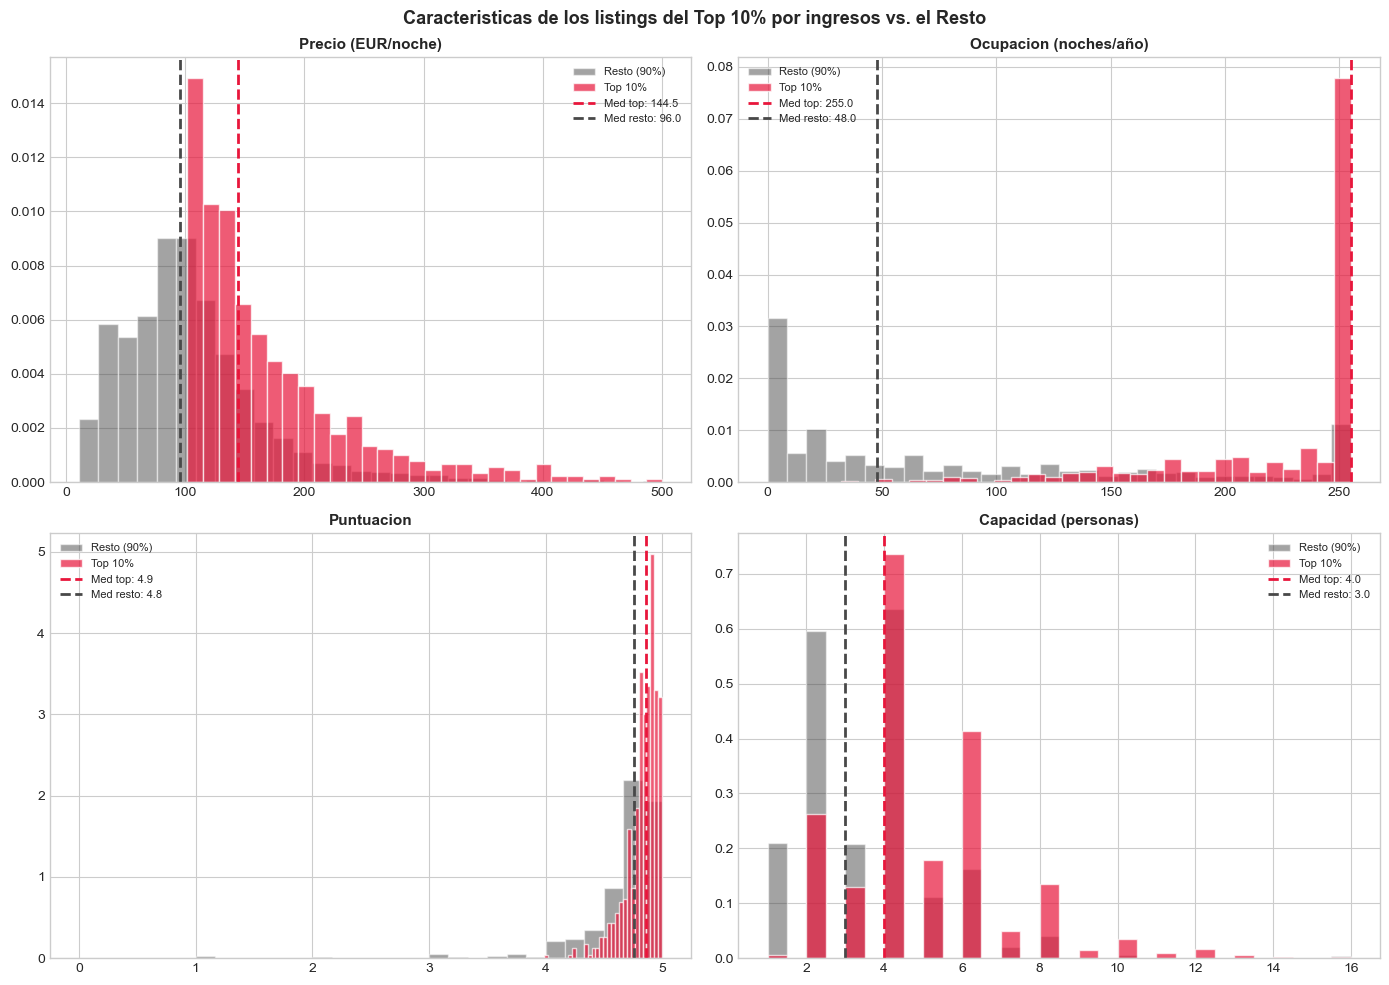

In [9]:
# Caracteristicas top hosts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, label, lim) in zip(axes.flatten(), [
    ('price_eur',                'Precio (EUR/noche)',          500),
    ('estimated_occupancy_l365d','Ocupacion (noches/año)',      None),
    ('review_scores_rating',     'Puntuacion',                  None),
    ('accommodates',             'Capacidad (personas)',         None),
]):
    data_top  = top_hosts[col].dropna()
    data_rest = rest_hosts[col].dropna()
    if lim:
        data_top  = data_top[data_top <= lim]
        data_rest = data_rest[data_rest <= lim]
    ax.hist(data_rest, bins=30, alpha=0.5, color=COLOR_SECONDARY,
            label='Resto (90%)', edgecolor='white', density=True)
    ax.hist(data_top,  bins=30, alpha=0.7, color=COLOR_PRIMARY,
            label='Top 10%',    edgecolor='white', density=True)
    ax.axvline(data_top.median(),  color=COLOR_PRIMARY,   linestyle='--', linewidth=2,
               label=f'Med top: {data_top.median():.1f}')
    ax.axvline(data_rest.median(), color=COLOR_SECONDARY, linestyle='--', linewidth=2,
               label=f'Med resto: {data_rest.median():.1f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Caracteristicas de los listings del Top 10% por ingresos vs. el Resto',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('25_top_host_characteristics.png')
plt.show()

## 6. Perfil del Host Optimo para un Nuevo Inversor

Guardado: 26_revenue_by_hood_and_segment.png


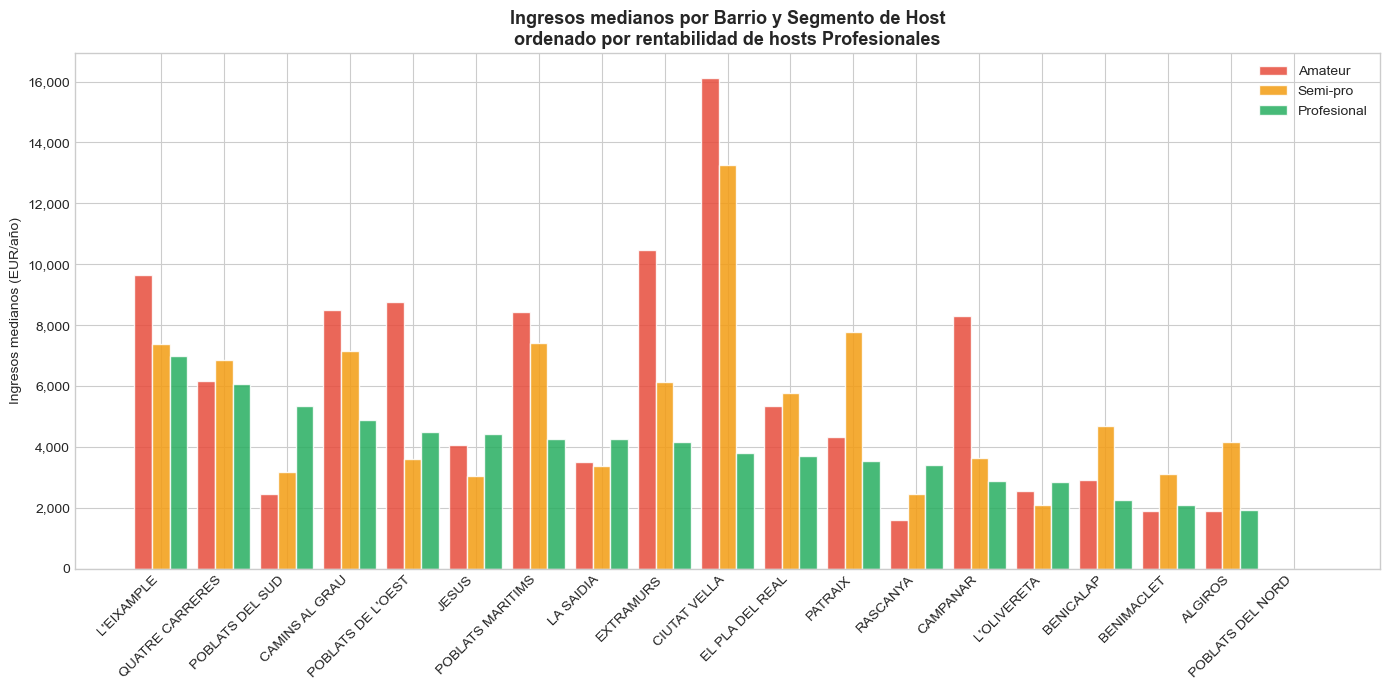

=== TOP 5 BARRIOS PARA HOST PROFESIONAL ===
neighbourhood_group_cleansed
L'EIXAMPLE          7000.00
QUATRE CARRERES     6060.00
POBLATS DEL SUD     5358.00
CAMINS AL GRAU      4896.00
POBLATS DE L'OEST   4506.00


In [10]:
# Barrio x Segmento: donde son mas rentables los profesionales?
hood_seg = df.groupby(['neighbourhood_group_cleansed', 'host_segment'])['estimated_revenue_l365d'].median().unstack()
hood_seg = hood_seg.reindex(columns=['Amateur', 'Semi-pro', 'Profesional'])
hood_seg = hood_seg.sort_values('Profesional', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(hood_seg))
width = 0.28
colors_seg = [COLOR_BAD, COLOR_WARN, COLOR_GOOD]

for i, (seg, color) in enumerate(zip(['Amateur', 'Semi-pro', 'Profesional'], colors_seg)):
    vals = hood_seg[seg].fillna(0)
    ax.bar(x + i*width - width, vals, width,
           label=seg, color=color, edgecolor='white', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(hood_seg.index, rotation=45, ha='right')
ax.set_ylabel('Ingresos medianos (EUR/año)')
ax.set_title('Ingresos medianos por Barrio y Segmento de Host\nordenado por rentabilidad de hosts Profesionales',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.tight_layout()
save_fig('26_revenue_by_hood_and_segment.png')
plt.show()

print('=== TOP 5 BARRIOS PARA HOST PROFESIONAL ===')
print(hood_seg['Profesional'].head(5).to_string())

In [11]:
# Guardar perfil de hosts procesado
host_profile = df.groupby('host_id').agg(
    n_listings       = ('id', 'count'),
    host_segment     = ('host_segment', 'first'),
    is_superhost     = ('host_is_superhost_bool', 'first'),
    total_revenue    = ('estimated_revenue_l365d', 'sum'),
    median_price     = ('price_eur', 'median'),
    median_rating    = ('review_scores_rating', 'median'),
    main_hood        = ('neighbourhood_group_cleansed', lambda x: x.mode()[0] if len(x) > 0 else None),
).reset_index()

host_profile.to_csv(PROCESSED_PATH / 'host_segments.csv', index=False)
print(f'host_segments.csv guardado: {host_profile.shape}')
print(f'\nHosts unicos: {host_profile["host_id"].nunique():,}')
print(f'Distribucion de segmentos:')
print(host_profile['host_segment'].value_counts())

host_segments.csv guardado: (3448, 8)

Hosts unicos: 3,448
Distribucion de segmentos:
host_segment
Amateur        2328
Semi-pro        919
Profesional     201
Name: count, dtype: int64


## 7. Conclusiones - Analisis de Hosts

Hallazgos clave:

1. Los Superhosts generan +461% mas ingresos que los hosts regulares (Mann-Whitney p<0.001)
2. Los hosts Profesionales (6+ listings) tienen mayor precio pero no proporcionalmente mas ingresos
3. El Top 10% por ingresos tiene: mayor capacidad (mas camas), mejor tasa de respuesta, mas instant bookable
4. Ser Superhost es el factor mas diferenciador para un nuevo inversor

Recomendaciones para un nuevo inversor:
- Obtener el badge Superhost desde el inicio: responder rapido (>90%), aceptar la mayoria de solicitudes
- Activar Instant Booking: los listings top 10% lo usan mas
- Priorizar capacidad: los alojamientos para 4+ personas generan mas ingresos
- Barrios recomendados para host profesional: ver tabla anterior

Proximo notebook: 05_investment_score.ipynb